In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from generator import calculate_spectral_GF, systemInit, setup_ham_rse, calculate_spectral_density

In [2]:

out_dir = Path("ldos_combos")
if not out_dir.exists():
    print("dir '{}' does not exist".format(out_dir))
else:
    print("dir '{}' exists!".format(out_dir))

dir 'ldos_combos' exists!


In [3]:
# dataN = np.load(data_dir / "ldos-conv-NN.npz")
# dataK = np.load(data_dir / "ldos-conv-k.npz")
# dataEta = np.load(data_dir / "ldos-conv-eta.npz")
# dE = 0.1
# Emax = 3.0 # eV
# Emin = - Emax
# energies = np.array([i*dE for i in range(-3, 4)]); #print(energies)

# fig, ax = plt.subplots(1,3, figsize=(12,6))

# for key, ldos_dev in dataN.items():
#     dos_dev = ldos_dev.sum(axis=0)
#     ax[0].plot(energies, dos_dev, label=f"$N = {key}$")
# for key, ldos_dev in dataK.items():
#     dos_dev = ldos_dev.sum(axis=0)
#     ax[1].plot(energies, dos_dev, label=f"$k = {key}$")
# for key, ldos_dev in dataEta.items():
#     dos_dev = ldos_dev.sum(axis=0)
#     ax[2].plot(energies, dos_dev, label=f"$\\eta = {key}$")

# for a in ax:
#     a.set_ylabel(r"$\mathrm{DOS}(E)\ \left[\mathrm{eV^{-1}\AA^{-2}}\right]$")
#     a.set_xlabel(r"$E\ \left[\mathrm{eV}\right]$")
#     a.legend()
#     a.grid()

# fig.suptitle("Comparing results around $E=0$ eV")


In [4]:
# fig, ax = plt.subplots(1,3, figsize=(12,6))


# dosE0_N = np.zeros(shape=(len(dataN)))
# ldosE0_N_diff = np.zeros_like(dosE0_N)
# Ns = np.zeros_like(dosE0_N)
# for i, (key, ldos_dev) in enumerate(dataN.items()):
    
#     dos_dev = ldos_dev.sum(axis=0)
#     nE = len(dos_dev)
#     Na = int(key)
#     ldosE0_N_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[Na//2, nE//2 +1])
#     print(f"site 0  and {Na//2:02} for {Na = }")
#     dosE0_N[i] = dos_dev[nE // 2 + 1]
#     Ns[i] = Na

# dosE0_k = np.zeros(shape=(len(dataK)))
# ldosE0_k_diff = np.zeros_like(dosE0_k)
# ks = np.zeros_like(dosE0_k)
# for i, (key, ldos_dev) in enumerate(dataK.items()):
#     dos_dev = ldos_dev.sum(axis=0)
#     nE = len(dos_dev)
#     ldosE0_k_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[7, nE//2 +1])
#     dosE0_k[i] = dos_dev[nE // 2 + 1]
#     ks[i] = float(key)
    
# dosE0_eta = np.zeros(shape=(len(dataEta)))
# ldosE0_eta_diff = np.zeros_like(dosE0_eta)
# etas = np.zeros_like(dosE0_eta, dtype=complex)
# for i, (key, ldos_dev) in enumerate(dataEta.items()):
#     dos_dev = ldos_dev.sum(axis=0)
#     nE = len(dos_dev)
    
#     ldosE0_eta_diff[i] = np.abs(ldos_dev[0, nE//2 + 1] - ldos_dev[7, nE//2 +1])
#     dosE0_eta[i] = dos_dev[nE // 2 + 1]
#     etas[i] = complex(key)


# for i, (x, y, y2, label) in enumerate(zip([Ns, ks, etas], [dosE0_N, dosE0_k, dosE0_eta], [ldosE0_N_diff, ldosE0_k_diff, ldosE0_eta_diff], ["N", "k-samplign", "$\\eta$"])):
#     ax[i].plot(x, y, 'k-', label=label)
#     ax[i].set_xlabel(f"{label}")
#     ax[i].set_ylabel(r"$\mathrm{DOS}(E=0)$")
    
#     ax2 = plt.twinx(ax[i])
#     ax2.plot(x, y2, 'r--')
#     ax2.set_ylabel(r"$\mathrm{LDOS}(E=0)$" + " @ $s=0$", color="r")
#     ax2.spines["right"].set_color("r")
#     ax2.tick_params(axis="y", color="r")
#     ax2.set_yticklabels(ax2.get_yticklabels(), color="r")
    
# for a in ax:
#     a.legend()
#     a.grid()

# fig.tight_layout()
# # fig.suptitle("Comparing results around $E=0$ eV")


# Compute GF and RSEs

In [5]:
N0 = N1 = 12
energies = np.array([-0.1, 0, 0.1])
eta = 1e-3
nk1 = int(np.ceil(2e3/N1))
Ham0 = systemInit()
H_final, rse, alist, elist = setup_ham_rse(Ham=Ham0, tile=(N0, N1), nk1=nk1, eta=eta)
output = calculate_spectral_GF(energies, eta, Ham_sub=H_final, rse=rse, alist=alist, elist=elist)
print(output.keys())

Looping energies:   0%|          | 0/3 [00:00<?, ?it/s]

dict_keys(['E', 'eta', 'H_re', 'electrode_idx', 'atoms_idx', 'GF', 'RSE'])


In [6]:
E0_idx,  = np.nonzero(energies == 0)
RSE_RE = output["RSE"]
RSE_E0 = RSE_RE[E0_idx]

def get_sign(val):
    if np.sign(val) < 0: return "-"
    elif np.sign(val) >= 0: return "+"

def complex_formatter(val):
    return f"({np.real(val):>5.2f} {get_sign(np.imag(val))} {np.abs(np.imag(val)):>6.2f}j)"

with np.printoptions(formatter={"bool": lambda val: f"{val}", "complex_kind": lambda val: complex_formatter(val)}, linewidth=160, edgeitems=3):
    print(RSE_E0)
    print(elist == output["electrode_idx"])

[[[(-0.00 - 2607.73j) ( 0.00 + 1447.50j) (-0.00 - 1278.60j) ... (-0.00 -   0.00j) (-0.00 -   0.00j) ( 0.00 +   0.00j)]
  [( 0.00 + 1447.50j) ( 0.00 - 1079.50j) (-0.00 + 1131.28j) ... ( 0.00 -   0.00j) (-0.00 -   0.00j) (-0.00 -   0.00j)]
  [(-0.00 - 1278.60j) (-0.00 + 1131.28j) ( 0.00 - 1306.78j) ... (-0.00 +   0.00j) ( 0.00 +   0.00j) (-0.00 +   0.00j)]
  ...
  [(-0.00 -   0.00j) ( 0.00 +   0.00j) (-0.00 -   0.00j) ... (-0.00 +   0.00j) ( 0.00 +   0.00j) (-0.00 +   0.00j)]
  [(-0.00 +   0.00j) (-0.00 -   0.00j) ( 0.00 +   0.00j) ... ( 0.00 +   0.00j) (-0.00 +   0.00j) ( 0.00 +   0.00j)]
  [( 0.00 +   0.00j) (-0.00 -   0.00j) (-0.00 -   0.00j) ... (-0.00 +   0.00j) ( 0.00 +   0.00j) (-0.00 +   0.00j)]]]
[True True True True True True True True True True True True True True True True True True True True True True True True True True True True True True True
 True True True True True True True True True True True True True True True]


1.1295218232953985e-15 -2607.727655405073


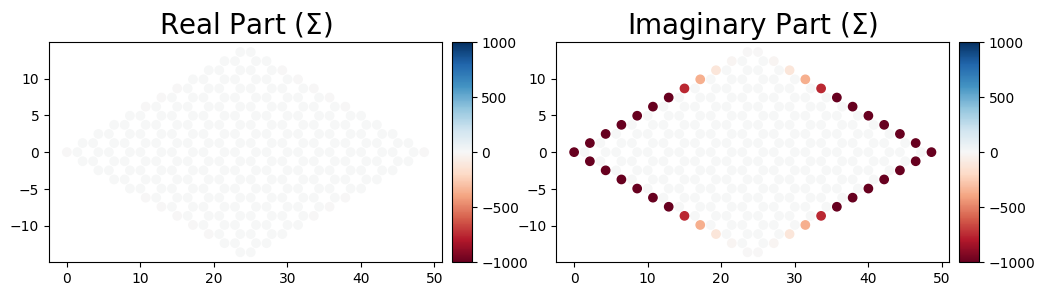

In [7]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
rse_diag = np.diagonal(RSE_RE, axis1=1, axis2=2).copy()
H = output["H_re"]
geomNN = H.geometry
x, y = H.geometry.xyz[:, :2].T

# Define the data parts and titles for a clean loop
E0_idx = np.nonzero(energies == 0)
data_parts = [rse_diag[E0_idx].real, rse_diag[E0_idx].imag]
titles = [r"Real Part ($\Sigma$)", r"Imaginary Part ($\Sigma$)"]

imag_min = rse_diag.imag.min()
imag_max = rse_diag.imag.max()

real_min = rse_diag.real.min()
real_max = rse_diag.real.max()

vmins = [np.min([imag_min, -imag_max]), np.min([real_min, -real_max])]
vmaxs = [np.max([-imag_min, imag_max]), np.max([-real_min, real_max])]
vmins = [-1e3,]*2
vmaxs = [1e3,]*2

print(imag_max, imag_min)


fig, ax = plt.subplots(1,2, figsize=(12,12))
for i in range(2):
    # Create the scatter plot
    sc = ax[i].scatter(x, y, c=data_parts[i], cmap="RdBu", 
                        vmin=vmins[i], vmax=vmaxs[i])
    
    ax[i].set_title(titles[i], size=20)
    ax[i].axis("scaled")
    
    # --- The Colorbar Logic ---
    # Create a divider for the current axes
    divider = make_axes_locatable(ax[i])
    # Append an axes to the right, 5% width of the main plot
    cax = divider.append_axes("right", size="5%", pad=0.1)
    fig.colorbar(sc, cax=cax)

# plt.tight_layout()
# plt.show()

 

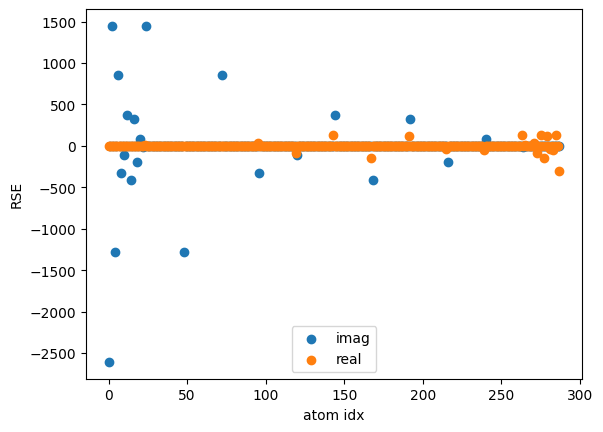

In [11]:
fig, ax = plt.subplots()
ax.scatter(alist, np.imag(RSE_E0).diagonal(), label="imag")
ax.scatter(alist, np.real(RSE_E0).diagonal(), label="real")
ax.set(xlabel="atom idx", ylabel="RSE")
ax.legend(loc="lower center")
